In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Layer, GlobalAveragePooling1D, GlobalMaxPooling1D

In [12]:
# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    TensorBoard(log_dir='./logs', histogram_freq=1, write_graph=True),
    ModelCheckpoint(filepath='main_no_cbam.keras', save_best_only=True),
]

In [13]:
# Lire le CSV
csv_file = './currencies_data.csv'

In [14]:
# Lire le fichiers CSV dans un DataFrame pandas
df = pd.read_csv(csv_file, thousands=',')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/21/2025,3865.36,3977.70,3985.78,3842.69,505.95K,-2.87%
1,10/20/2025,3979.43,3982.68,4083.67,3909.40,549.92K,-0.08%
2,10/19/2025,3982.53,3889.19,4028.09,3844.52,463.11K,2.41%
3,10/18/2025,3888.87,3835.39,3927.37,3821.16,271.11K,1.49%
4,10/17/2025,3831.60,3894.48,3950.32,3679.90,880.38K,-1.61%


In [ ]:
data = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(data)

In [16]:
look_back = 30
generator = TimeseriesGenerator(normalized_data, normalized_data, length=look_back, batch_size=32)

In [20]:
model = Sequential([
    LSTM(50, input_shape=(look_back, 1)),
    Dense(1)
])

/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.fit(generator, epochs=20, verbose=1, batch_size=32, callbacks=callbacks)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 5.5648e-04 - loss: 0.0390 - learning_rate: 0.0010
Epoch 2/20
 6/57 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0063 - loss: 0.0049    

/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)
/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0011 - loss: 0.0030 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0011 - loss: 0.0025 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0011 - loss: 0.0026 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0011 - loss: 0.0024 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0011 - loss: 0.0023 - learning_rate: 0.0010
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0011 - loss: 0.0025 - learning_rate: 0.0010
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0011 - loss: 0.0023 - learning_rate: 0.0010
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0011 - loss: 0.0018 - learning_rate: 0.0010
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0011 - loss: 0.0019 - learning_rate: 0.0010
Epoch 11/20
57/57 ━━━━━━━━━━━

In [22]:
test_generator = TimeseriesGenerator(normalized_data, normalized_data, length=look_back, batch_size=1)
predictions = model.predict(test_generator)
predictions = scaler.inverse_transform(predictions)

  30/1797 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step 

/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1797/1797 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


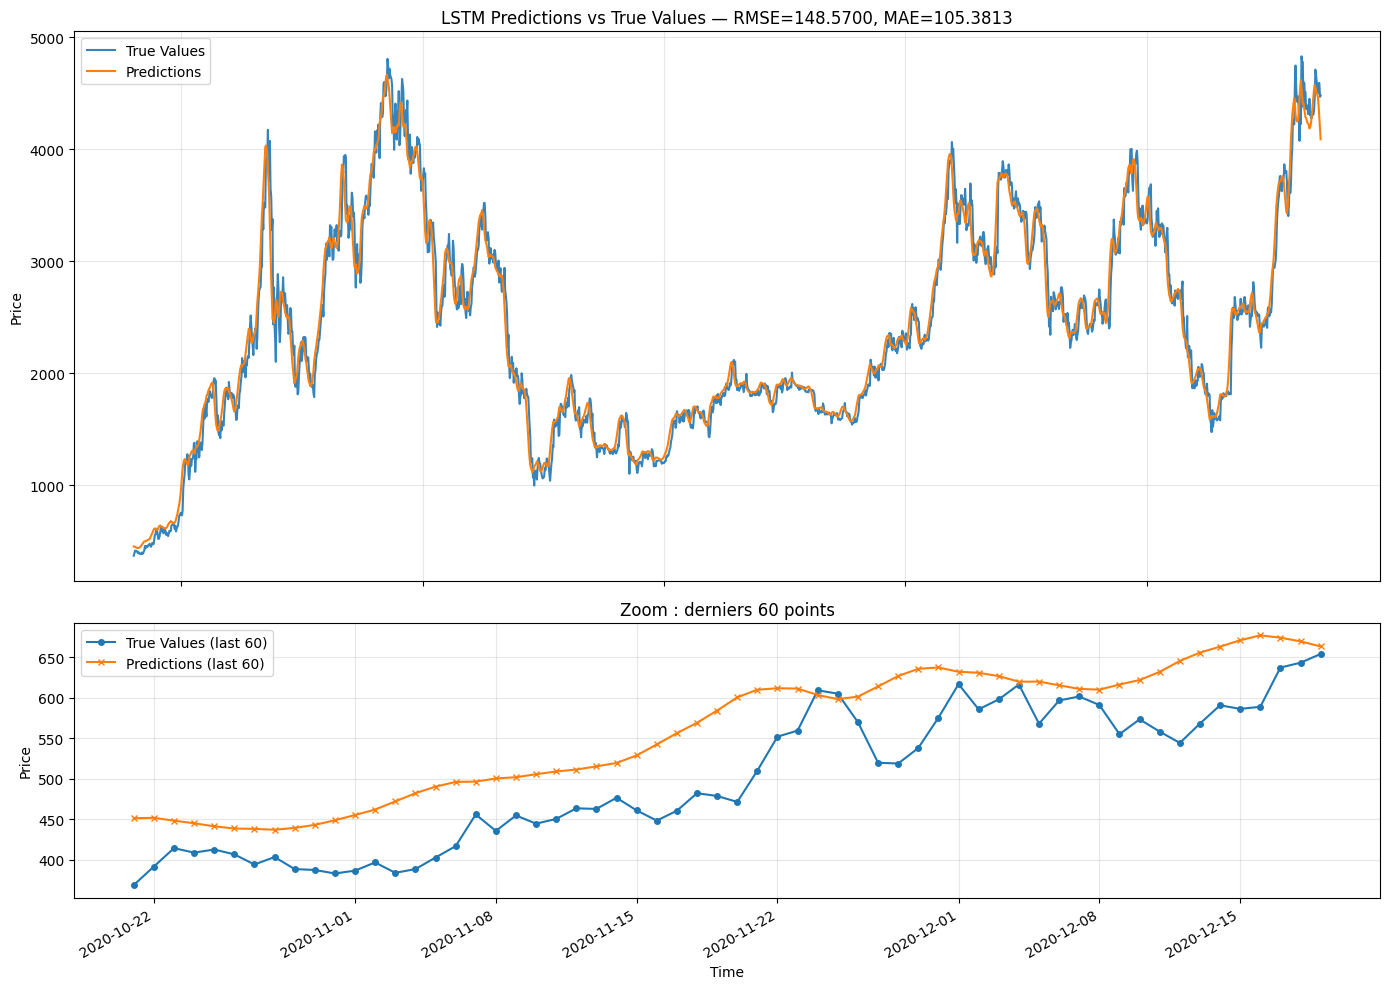

In [ ]:
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Préparer les séries
trues_values = data[look_back:].reshape(-1)         # True values (unidimensionnel)
preds = predictions.reshape(-1)                     # Predictions (unidimensionnel)

try:
    time_index = pd.to_datetime(df['Date'], errors='coerce')
    if time_index.isna().all():
        raise ValueError("Date column all NaT -> fallback to positional index")
    time_all = time_index.iloc[look_back:].to_numpy()   # numpy array (datetime64[ns]) ou object (Timestamp)
except Exception:
    time_all = np.arange(len(data))[look_back:]

rmse = np.sqrt(mean_squared_error(trues_values, preds))
mae = mean_absolute_error(trues_values, preds)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(time_all, trues_values, label='True Values', color='tab:blue', alpha=0.9)
ax1.plot(time_all, preds, label='Predictions', color='tab:orange', alpha=0.8)
ax1.set_title(f'LSTM Predictions vs True Values — RMSE={rmse:.4f}, MAE={mae:.4f}')
ax1.set_ylabel('Price')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left')

if hasattr(time_all, 'dtype') and np.issubdtype(time_all.dtype, np.datetime64):
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate(rotation=30)

last_n = 60
n = min(last_n, len(trues_values))
zoom_idx = slice(-n, None)

ax2.plot(time_all[zoom_idx], trues_values[zoom_idx], label=f'True Values (last {n})', color='tab:blue', marker='o', markersize=4)
ax2.plot(time_all[zoom_idx], preds[zoom_idx], label=f'Predictions (last {n})', color='tab:orange', marker='x', markersize=4)
ax2.set_title(f'Zoom : derniers {n} points')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left')

if hasattr(time_all, 'dtype') and np.issubdtype(time_all.dtype, np.datetime64):
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()